In [1]:
import warnings
import gc
from pathlib import Path

import numpy as np
import cv2
import torch
import torch.nn.functional as F
from PIL import Image
from matplotlib import pyplot as plt

from wan import CustomWanI2V
from wan.configs.wan_i2v_14B import i2v_14B
from wan.utils.utils import cache_video

from torchcodec.decoders import VideoDecoder
from torchvision import transforms

warnings.filterwarnings("ignore", category=FutureWarning, message=".*torch.cuda.amp.autocast.*")

In [2]:
wan_i2v = CustomWanI2V(
    config=i2v_14B,
    checkpoint_dir="./weights/Wan2.1-I2V-14B-480P/",
    device_id=0,
    t5_cpu=True,
)

Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

In [34]:
img_file = Path("examples/women_looking_at_each_other.jpg")
# img_file = Path("examples/girl_looking_at_guy.jpg")
img = Image.open(img_file).convert("RGB")

target_size = (480, 832)

transform = transforms.Compose(
    [transforms.Resize(min(target_size)), transforms.CenterCrop(target_size)]
)
img = transform(img)

transformed_img_file = img_file.with_stem(img_file.stem + "_transformed")
img.save(transformed_img_file, quality=95)

In [35]:
import json


with open(transformed_img_file.with_suffix(".json")) as f:
    annotations = json.load(f)

face_bboxes_dict = {
    shape["label"]: shape["points"]
    for shape in annotations["shapes"]
    if shape["shape_type"] == "rectangle"
}

people_bboxes = []

for shape in annotations["shapes"]:
    if shape["shape_type"] != "rectangle":
        continue

    xy1, xy2 = shape["points"]
    bbox = [round(x) for x in xy1 + xy2]
    people_bboxes.append(bbox)


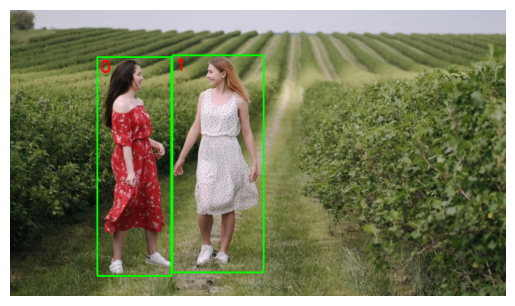

In [36]:
img_bgr = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)


for idx, bbox in enumerate(people_bboxes):
    # x1, y1, x2, y2 = map(round, bbox)
    x1, y1, x2, y2 = bbox

    cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color=(0, 255, 0), thickness=2)
    cv2.putText(img_bgr, str(idx), (x1 + 5, y1 + 25), cv2.FONT_HERSHEY_SIMPLEX,
                fontScale=0.9, color=(0, 0, 255), thickness=2)

# Convert back to RGB for displaying with matplotlib
img_arr = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display in Jupyter notebook
# plt.figure(figsize=(8, 8))
plt.imshow(img_arr)
plt.axis('off')
plt.show()

In [37]:
def create_bbox_mask(bbox, image_size):
    """
    Creates a boolean mask for a bounding box.
    """
    left, top, right, bottom = bbox
    height, width = image_size

    y_coords, x_coords = torch.meshgrid(torch.arange(height), torch.arange(width), indexing="ij")

    # this looks counter-inutitive, but with meshgrid the origin is the top-left corner
    mask = (y_coords >= top) & (y_coords < bottom) & (x_coords >= left) & (x_coords < right)

    return mask


w, h = img.size
face_masks = torch.stack([create_bbox_mask(bbox, (h, w)) for bbox in people_bboxes])

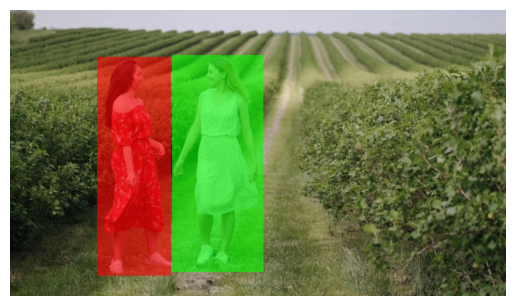

In [38]:
colors = [
    [0, 0, 255],   # Red
    [0, 255, 0],   # Green
    [255, 0, 0],   # Blue
    [255, 255, 0]  # Cyan
]

img_bgr = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

overlay = img_bgr.copy()

for i, mask in enumerate(face_masks.numpy()):
    color = colors[i % len(colors)]
    overlay[mask] = color

alpha = 0.6  # Transparency factor
highlighted_image = cv2.addWeighted(overlay, alpha, img_bgr, 1 - alpha, 0)

plt.imshow(cv2.cvtColor(highlighted_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [39]:
frame_num = 81  # default
pad = torch.zeros(frame_num, dtype=bool)

a_looks_b = torch.zeros(frame_num, dtype=bool)
a_looks_b[:40] = True

b_looks_a = torch.zeros(frame_num, dtype=bool)
b_looks_a[40:] = True

#           ┌───────── Observed ─────────┐
#           │         A            B     │
# ┌─────────┼────────────────────────────┤
# │         │   ┌───────────┬───────────┐│
# │         │ A │    i=0    │    i=1    ││
# │         │   │    j=0    │    j=0    ││
# │Observer │   ├───────────┼───────────┤│
# │         │ B │    i=1    │    i=1    ││
# │         │   │    j=0    │    j=1    ││
# │         │   └───────────┴───────────┘│
# └─────────┴────────────────────────────┘


wlw_matrix = torch.stack([pad, a_looks_b, b_looks_a, pad]).reshape(2, 2, -1)
assert (wlw_matrix[0, 1] == a_looks_b).all()
assert (wlw_matrix[1, 0] == b_looks_a).all()

In [41]:
# prompt = "Two young women, dressed in summer dresses, are walking and conversing in a vast, verdant field. The woman on the left has long, dark brown hair and is wearing a flowing, off-the-shoulder red dress with white patterns, looking towards her companion and smiling. The woman on the right has lighter, possibly reddish-blonde hair and is wearing a white sleeveless dress with small dark polka dots, also smiling and looking at her friend; both are wearing white sneakers. A narrow, grassy path is visible between rows of what appear to be young green bushes or crops, possibly berry bushes, stretching far into the background, with the rows creating a strong sense of perspective, converging towards the horizon under an overcast sky that suggests a soft, diffused light, contributing to the overall natural, serene, and friendly atmosphere of this relaxed interaction in an open agricultural landscape."

prompt = "Two smiling young women in summer dresses and white sneakers walk and converse in a vast, green field of uniform crop rows receding into the distance. The woman on the left wears a red, off-the-shoulder dress, while the woman on the right wears a white polka-dot dress. An overcast sky provides soft, diffused light over the serene agricultural landscape."
negative_prompt = "Bright tones, overexposed, static, blurred details, subtitles, style, works, paintings, images, static, overall gray, worst quality, low quality, JPEG compression residue, ugly, incomplete, extra fingers, poorly drawn hands, poorly drawn faces, deformed, disfigured, misshapen limbs, fused fingers, still picture, messy background, three legs, many people in the background, walking backwards"

descr_list = [
    "the woman on the left wearing a red, off-the-shoulder dress",
    "the woman on the right wearing a white polka-dot dress",
]

# link_list = ["is looking at", "is not looking at"]
link_text = "is looking at"

sampling_steps = 40

timestep_bias_schedule = torch.zeros(sampling_steps, dtype=bool)
timestep_bias_schedule[:max(1, sampling_steps // 2)] = True
# timestep_bias_schedule[10:30] = True

num_layers = wan_i2v.model.num_layers
blocks_bias_schedule = torch.zeros(num_layers, dtype=bool)
# blocks_bias_schedule[:max(1, int(num_layers * 3 / 4))] = True
blocks_bias_schedule[:] = True

bias_kwargs = {
    "descr_list": descr_list,
    "link_text": link_text,
    "timestep_bias_schedule": timestep_bias_schedule,
    "blocks_bias_schedule": blocks_bias_schedule,
    "face_masks": face_masks,
    "wlw_matrix": wlw_matrix,
    "beta": 0.0,
}

torch.cuda.synchronize()
gc.collect()
torch.cuda.empty_cache()
video, simil_masks = wan_i2v.generate(
    prompt,
    img,
    bias_kwargs,
    max_area=target_size[0] * target_size[1],
    n_prompt=negative_prompt,
    sampling_steps=sampling_steps,
    frame_num=frame_num,
)

  0%|          | 0/40 [00:00<?, ?it/s]

82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82


  2%|▎         | 1/40 [00:44<28:50, 44.37s/it]

82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82


  5%|▌         | 2/40 [01:29<28:20, 44.74s/it]

...

 95%|█████████▌| 38/40 [28:14<01:28, 44.02s/it]

82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82


 98%|█████████▊| 39/40 [28:58<00:44, 44.03s/it]

82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82
82


100%|██████████| 40/40 [29:42<00:00, 44.56s/it]


In [42]:
def create_mask_from_bbox(mask):
    """
    Finds the single bounding box that most closely matches a binary mask.
    """
    if isinstance(mask, torch.Tensor):
        mask = mask.numpy().astype(np.uint8)
    elif not isinstance(mask, np.ndarray):
        raise TypeError("Input mask must be a numpy array or a torch tensor.")

    if mask.dtype != np.uint8:
        mask = mask.astype(np.uint8)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    largest_contour = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(largest_contour)

    return (x, y, x + w, y + h)

In [43]:
def normalize_tensor(
    tensor: torch.Tensor,
    value_range: tuple = (-1, 1)
) -> torch.Tensor:
    tensor = tensor.clamp(min(value_range), max(value_range))

    min_val, max_val = value_range
    tensor = (tensor - min_val) / (max_val - min_val)

    # (C, T, H, W) -> (T, H, W, C)
    tensor = tensor.permute(1, 2, 3, 0)

    return (tensor * 255).type(torch.uint8)


video_norm = normalize_tensor(video.cpu())


In [44]:
h, w = video.shape[-2:]

face_masks = simil_masks[0, -1].float().mean(dim=0) > 0.5
# face_masks = simil_masks[0, -1].float().mean(dim=0) * 255
# face_masks = simil_masks[0, -1, -1]
# face_masks = simil_masks[0].float().mean(dim=[0,1]) > 0.5
# face_masks = simil_masks[0].float().mean(dim=[0,1]) * 255

face_masks = F.interpolate(
    face_masks.unsqueeze(1).float(), size=(frame_num, h, w), mode="nearest"
).bool().squeeze(1)

In [45]:
def produce_debug_video(video, save_file, wlw, face_masks, fps=16):
    _, h, w, _ = video.shape
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(save_file, fourcc, fps, (w, h))

    RED = (0, 0, 255)
    BLUE = (255, 0, 0)

    for frame, frame_wlw, frame_face_masks in zip(video, wlw, face_masks, strict=True):
        frame = np.ascontiguousarray(frame.numpy())
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

        bboxes = [create_mask_from_bbox(mask) for mask in frame_face_masks]

        for bbox, is_looking in zip(bboxes, frame_wlw):
            cv2.rectangle(
                frame,
                [bbox[0], bbox[1]],
                [bbox[2], bbox[3]],
                RED if is_looking else BLUE,
                thickness=2,
            )

        writer.write(frame)

    writer.release()

In [46]:
produce_debug_video(
    video_norm,
    "debug_example.mp4",
    wlw_matrix[[0, 1], [1, 0], :].transpose(0, 1),
    face_masks.transpose(0, 1),
    fps=4,
)